In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/wine_data.csv',header=None , usecols=[0,1,2])
df.columns=['class label','Alcohol','Malic Acid']


In [3]:
df

,class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

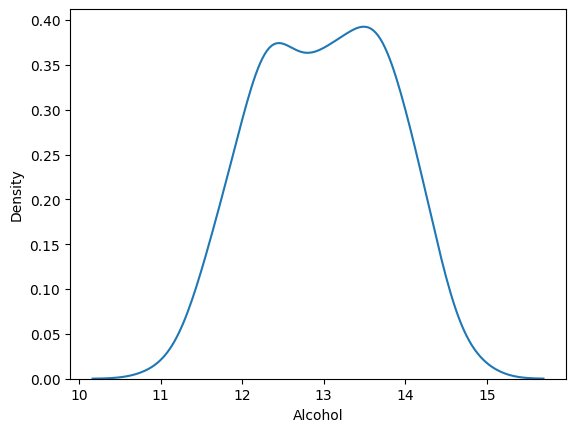

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

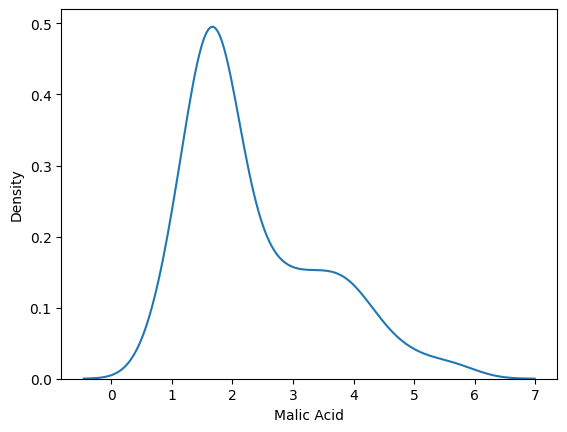

In [5]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

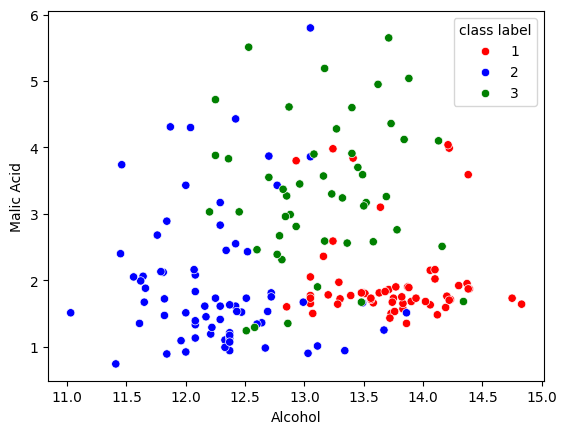

In [7]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue =df['class label'],palette=color_dict)

In [8]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test =train_test_split(df.drop('class label',axis=1),
                                                     df['class label'],
                                                     test_size=0.3,
                                                     random_state=0)

In [11]:
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)
 #Transfer the data to min max using formula {xi=xi-xmin/xmax-xmin}

X_train_Scaler = scaler.transform(X_train)
X_test_Scaler = scaler.transform(X_test)

In [18]:
X_train_Scaler=pd.DataFrame(X_train_Scaler,columns=X_train.columns)
X_test_Scaler=pd.DataFrame(X_test_Scaler,columns=X_test.columns)

In [19]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [20]:
np.round(X_train_Scaler.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


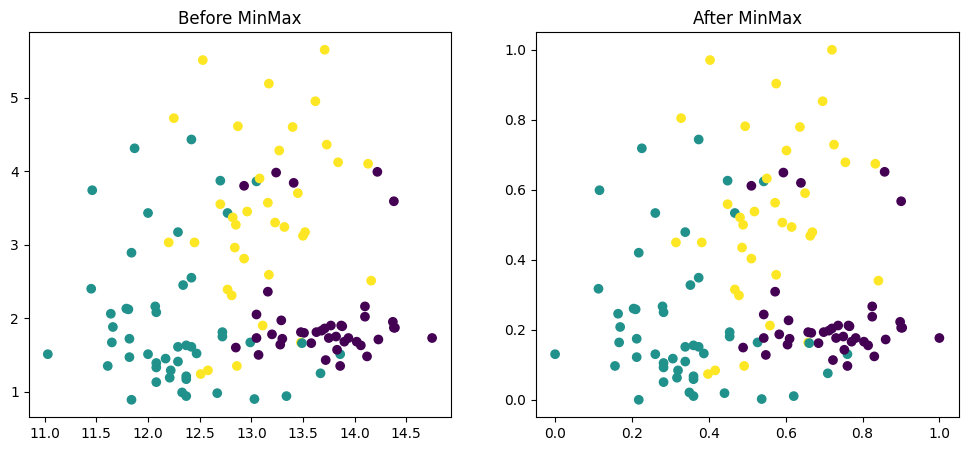

In [24]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))


ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'],c=y_train)
ax1.set_title("Before MinMax")


ax2.scatter(X_train_Scaler['Alcohol'],X_train_Scaler['Malic Acid'],c=y_train)
ax2.set_title("After MinMax")


plt.show()

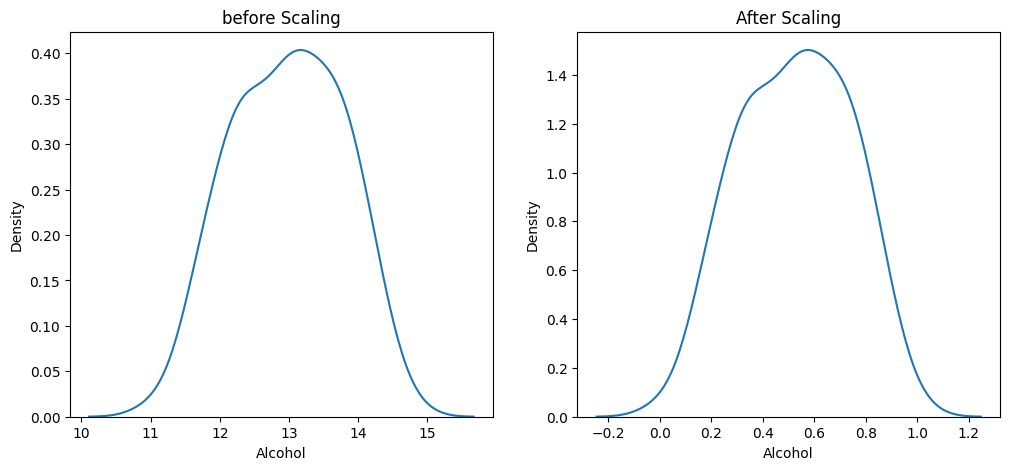

In [27]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))


#Before Scalling
ax1.set_title("before Scaling")
sns.kdeplot(X_train['Alcohol'],ax=ax1)

#After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaler['Alcohol'],ax=ax2)

plt.show()

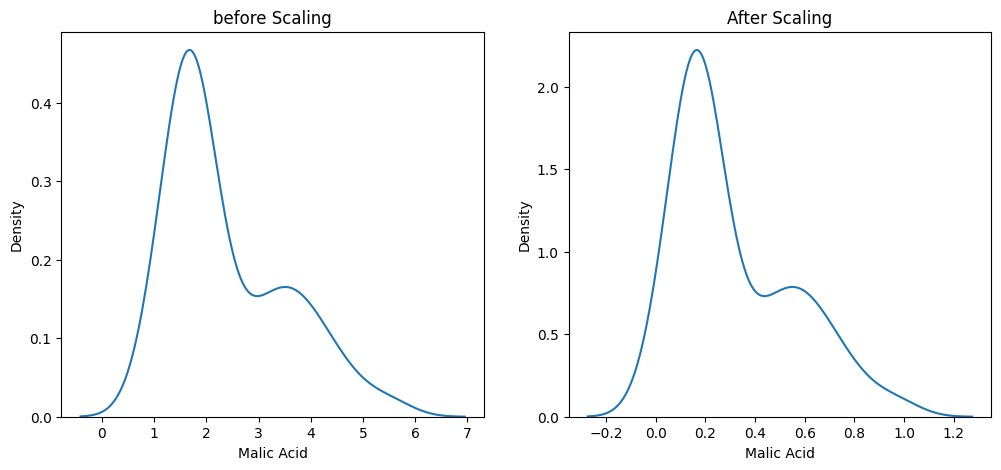

In [28]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))


#Before Scalling
ax1.set_title("before Scaling")
sns.kdeplot(X_train['Malic Acid'],ax=ax1)

#After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaler['Malic Acid'],ax=ax2)

plt.show()

#With outlier it is may be not that good

#*Mean Normalization *

#Formula
Xi= x-xmean/xmax-xmin

##MaxAbs scalling

#Formula
X'=xi/xmax

Used when there is more zeros (0)


#Robost Scaling


#1. Formula == xi'=xi-xmean/IQR(75th % -25th %_)

Robustscler in sklearn.preprocessor


2.Uses
IF there is a lot of outliers


#Normalization Vs Standardlization

mainly used standardlization  ,
noramlization used when max and value is known like image processing ,outliers and here and there